In [20]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("NIFTY50_all.csv", parse_dates=["Date"])

In [3]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [4]:
 #Keep only relevant columns
df = df[["Date", "Symbol", "Close"]]

In [5]:
df.head()

,Date,Symbol,Close
0,2007-11-27,MUNDRAPORT,962.90
1,2007-11-28,MUNDRAPORT,893.90
2,2007-11-29,MUNDRAPORT,884.20
3,2007-11-30,MUNDRAPORT,921.55
4,2007-12-03,MUNDRAPORT,969.30


Reshape the data with Date as Index, stocks as columns. a

In [6]:
prices = df.pivot(index="Date", columns="Symbol", values="Close")

In [7]:
prices.head()

Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJAUTOFIN,BAJFINANCE,BHARTI,BHARTIARTL,BPCL,...,TISCO,TITAN,ULTRACEMCO,UNIPHOS,UPL,UTIBANK,VEDL,WIPRO,ZEEL,ZEETELE
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,381.65,NaN,NaN,NaN,50.75,NaN,NaN,NaN,399.25,...,152.45,155.70,NaN,NaN,NaN,26.70,NaN,2724.20,NaN,1179.95
2000-01-04,NaN,385.55,NaN,NaN,NaN,48.10,NaN,NaN,NaN,370.50,...,150.80,147.40,NaN,NaN,NaN,26.85,NaN,2942.15,NaN,1260.65
2000-01-05,NaN,383.00,NaN,NaN,NaN,44.60,NaN,NaN,NaN,359.95,...,156.55,138.40,NaN,NaN,NaN,26.30,NaN,2990.10,NaN,1176.55
2000-01-06,NaN,377.50,NaN,NaN,NaN,45.25,NaN,NaN,NaN,380.30,...,168.25,149.50,NaN,NaN,NaN,25.95,NaN,2932.25,NaN,1115.45
2000-01-07,NaN,385.70,NaN,NaN,NaN,42.90,NaN,NaN,NaN,379.85,...,171.95,146.35,NaN,NaN,NaN,24.80,NaN,2697.70,NaN,1026.25


There are stocks like Reliance (trading since 1995) and stocks like Zomato or Jio Financial (trading only recently), we are getting alot of missing values for various stocks.

### Cleaning Strategy
We select a start date and end date for the problem setup. The data contains stock prices till 30th April of 2021. We will select data from 2015 to 2019. We check the very first row (start_date). If a stock is NaN there, it means it wasn't listed yet. We will drop these stocks.

In [8]:
start_date = "2015-01-01"
end_date = "2019-12-31"
prices = prices.loc[start_date:end_date]

In [9]:
valid_stocks = prices.iloc[0].dropna().index
prices = prices[valid_stocks]

In [10]:
print(f"Dropped {len(df['Symbol'].unique()) - len(valid_stocks)} stocks because they weren't listed by {start_date}.")

Dropped 16 stocks because they weren't listed by 2015-01-01.


In [11]:
prices.isnull().sum()

Symbol
ADANIPORTS       0
ASIANPAINT       0
AXISBANK         0
BAJAJ-AUTO       0
BAJAJFINSV       0
BAJFINANCE       0
BHARTIARTL       0
BPCL             0
BRITANNIA        0
CIPLA            0
COALINDIA        0
DRREDDY          0
EICHERMOT        0
GAIL             0
GRASIM           0
HCLTECH          0
HDFC             0
HDFCBANK         0
HEROMOTOCO       0
HINDALCO         0
HINDUNILVR       0
ICICIBANK        0
INDUSINDBK       0
INFY             0
IOC              0
ITC              0
JSWSTEEL         0
KOTAKBANK        0
LT               0
M&M              0
MARUTI           0
NESTLEIND        0
NTPC             0
ONGC             0
POWERGRID        0
RELIANCE         0
SBIN             0
SHREECEM         0
SSLT          1150
SUNPHARMA        0
TATAMOTORS       0
TATASTEEL        0
TCS              0
TECHM            0
TITAN            0
ULTRACEMCO       0
UPL              0
WIPRO            0
ZEEL             0
dtype: int64

SSLT has missing values. Hence we will simply drop the column.

In [12]:
prices = prices.drop(columns=["SSLT"])

In [13]:
prices.head()

Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,SUNPHARMA,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,WIPRO,ZEEL
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,319.55,749.15,503.05,2452.15,1286.60,3499.70,362.90,654.20,1831.50,628.40,...,822.20,498.45,404.45,2545.55,2594.55,379.8,2662.50,341.60,552.40,377.70
2015-01-02,319.35,775.05,514.30,2451.75,1275.65,3443.75,365.05,644.40,1878.55,630.15,...,826.25,511.80,410.75,2579.45,2607.25,382.8,2742.10,352.25,557.30,380.95
2015-01-05,323.80,775.00,517.55,2460.70,1258.70,3434.75,356.95,645.65,1879.85,633.00,...,826.75,523.80,416.70,2540.25,2563.75,385.9,2747.70,345.70,558.30,380.00
2015-01-06,321.85,756.50,499.05,2441.50,1229.60,3425.85,354.15,639.15,1881.90,614.35,...,808.55,501.40,396.50,2446.60,2536.25,372.7,2670.60,328.95,545.25,367.90
2015-01-07,321.10,771.70,498.65,2447.20,1228.55,3495.60,355.00,644.95,1995.75,611.95,...,809.80,493.85,388.90,2417.70,2524.40,374.6,2660.05,323.05,541.10,364.85


### Computing Yearly Returns
We take the closing value at the end of the year and compute the yearly percent change. 

In [14]:
year_end = prices.resample("YE").last()

# Compute yearly percentage returns
yearly_returns = year_end.pct_change().dropna()

yearly_returns

Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,SUNPHARMA,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,WIPRO,ZEEL
Date,,,,,,,,,,,,,,,,,,,,,
2016-12-31,0.028938,0.008488,0.001893,0.039573,0.456235,-0.859866,-0.102086,-0.287796,-0.026970,-0.124586,...,-0.231848,0.206236,0.505966,-0.029259,-0.062782,-0.058620,0.168905,0.476832,-0.152617,0.036135
2017-12-31,0.511082,0.300152,0.253361,0.266469,0.806795,1.085847,0.732864,-0.185366,0.631587,0.069796,...,-0.093413,-0.085064,0.871949,0.141891,0.030988,1.625918,0.329334,0.178825,-0.337654,0.284185
2018-12-31,-0.044250,0.185196,0.099211,-0.184020,0.238328,0.505749,-0.409988,-0.299305,-0.338451,-0.146261,...,-0.246258,-0.600093,-0.288572,-0.299182,0.434679,0.084892,-0.076297,-0.005835,0.052824,-0.181076
2019-12-31,-0.055971,0.299989,0.216487,0.170891,0.450274,0.600949,0.458560,0.355065,-0.028118,-0.079500,...,0.004762,0.072090,-0.094041,0.141914,0.054138,0.275994,0.013806,-0.229146,-0.257065,-0.386714


Computing expected returns and covariance.

In [15]:
mu = yearly_returns.mean().values  #
Sigma = yearly_returns.cov().values
n = len(mu)

In [18]:
w = cp.Variable(n)

# setup target return
target_return = 0.10

# Objective: minimize risk
objective = cp.Minimize(cp.quad_form(w, Sigma))

# Constraints
constraints = [
    mu.T @ w >= target_return,
    cp.sum(w) == 1,
    w >= 0 # no short selling
]

In [19]:
# Solve with ECOS
prob = cp.Problem(objective, constraints)
result = prob.solve(solver=cp.ECOS)

weights = w.value
print("Optimal Value:", result)
print("Weights:", weights)

Optimal Value: 6.297933075519092e-14
Weights: [0.01137388 0.02549964 0.01907683 0.01223327 0.0318788  0.02444171
 0.00999757 0.01195644 0.00842262 0.01038862 0.01131502 0.01951595
 0.01081694 0.00727141 0.00689661 0.01083792 0.02021483 0.01105913
 0.0097944  0.01322372 0.01912722 0.03524989 0.01218906 0.00966031
 0.00652419 0.01175141 0.1455431  0.02951314 0.01675899 0.01210014
 0.00954946 0.1273097  0.01033526 0.00901861 0.01493555 0.07034299
 0.01467349 0.01686692 0.00985739 0.00858312 0.00983148 0.01055794
 0.04545567 0.0111507  0.01279184 0.01337184 0.01222638 0.00850893]


### Efficient Frontier Plot for Different Target Returns

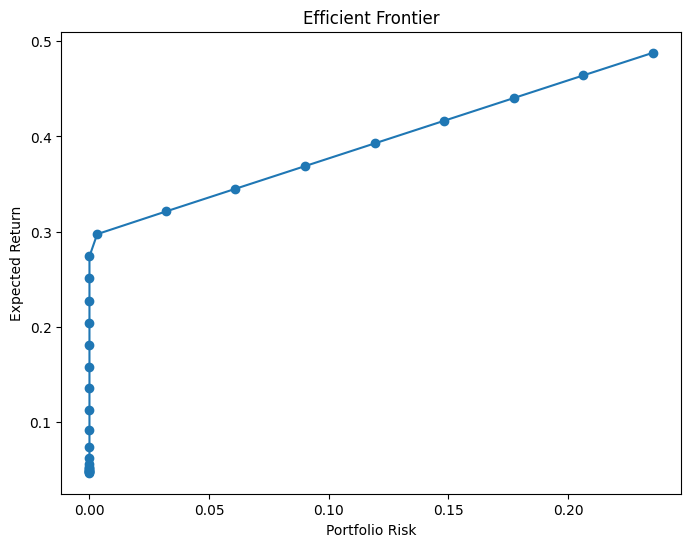

In [22]:
# decision variable
w = cp.Variable(n)

# portfolio variance
risk = cp.quad_form(w, Sigma)

# objective
objective = cp.Minimize(risk)

# base constraints
constraints = [
    cp.sum(w) == 1,
    w >= 0
]

# target returns grid
target_returns = np.linspace(mu.min(), mu.max(), 30)

risks = []
returns = []

for r in target_returns:
    # add return constraint
    ret_constraint = mu.T @ w >= r
    prob = cp.Problem(objective, constraints + [ret_constraint])
    
    prob.solve(solver=cp.ECOS)
    
    if w.value is not None:
        risks.append(np.sqrt(risk.value))  # standard deviation
        returns.append(mu @ w.value)

# plot efficient frontier
plt.figure(figsize=(8,6))
plt.plot(risks, returns, marker='o')
plt.xlabel("Portfolio Risk")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.show()

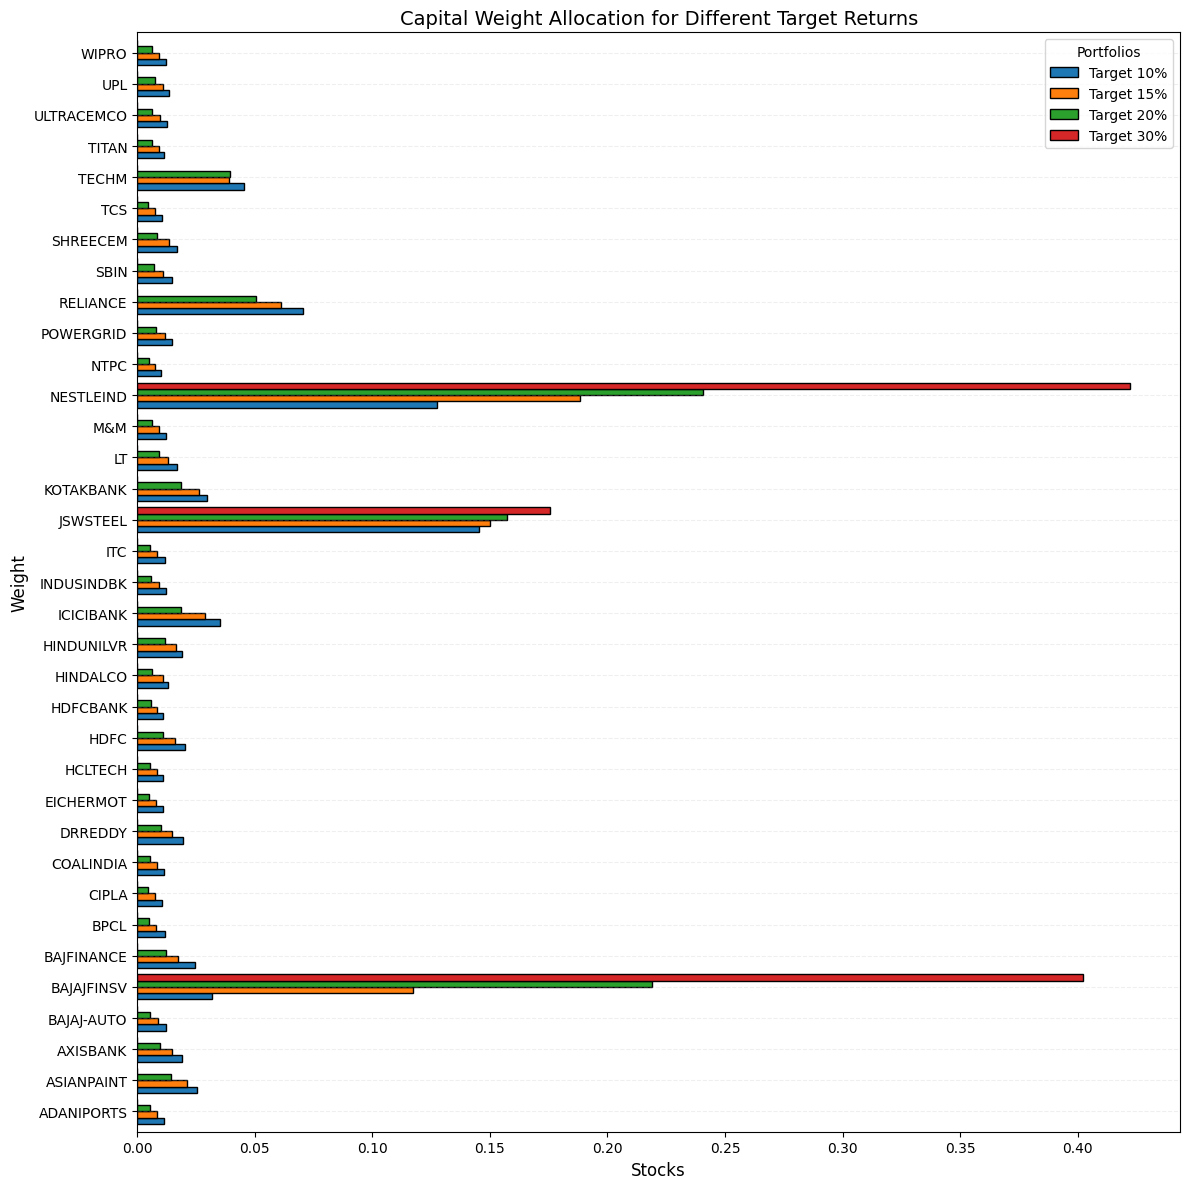

In [30]:
target_returns = [0.10, 0.15, 0.20, 0.30, ] 

# DataFrame to store weights (Index = Stock Names, Columns = Scenarios)
allocation_df = pd.DataFrame(index=prices.columns)

for r in target_returns:
    w = cp.Variable(n)
    
    risk = cp.quad_form(w, Sigma)
    objective = cp.Minimize(risk)
    
    constraints = [
        mu @ w >= r,
        cp.sum(w) == 1, 
        w >= 0
    ]
    
    # Solve
    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.ECOS)
        
        # Store result in DataFrame with a descriptive column name
        if w.value is not None:
            allocation_df[f"Target {r:.0%}"] = np.round(w.value, 4)
        else:
            print(f"Solver failed for target {r:.0%}")
            
    except Exception as e:
        print(f"Optimization failed for {r:.0%}: {e}")

active_stocks = allocation_df[(allocation_df > 0.01).any(axis=1)]

# Plotting
ax = active_stocks.plot(
    kind='barh', 
    figsize=(12, 12), 
    width=0.8,             
    edgecolor='black'     
)

plt.title("Capital Weight Allocation for Different Target Returns", fontsize=14)
plt.xlabel("Stocks", fontsize=12)
plt.ylabel("Weight", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.legend(title="Portfolios", loc="upper right")
plt.tight_layout()

plt.show()

## Insights from the Histogram

1. Low Target (10% - Blue): The capital is more evenly spread out. We can see blue bars present for almost every stock listed, indicating a diversified approach to achieve a modest, safer return.
2. High Target (30% - Red): The portfolio becomes extremely concentrated. The red bars disappear for the vast majority of stocks and spike massively for just 2-3 specific companies. 
3. Three stocks dominate the allocation, particularly for higher return targets:

    * NESTLEIND (Nestle India): This is the single most important stock for high returns in this model. For the 30% target, it commands over 40% of the entire portfolio (0.4+ weight). It is also heavily weighted for the 20% target.

    * BAJAJFINSV (Bajaj Finserv): Similar to Nestle, this stock is essential for the aggressive portfolios. It holds nearly 40% weight in the 30% target portfolio.

    * JSWSTEEL: It maintains a significant weight across all targets (10% to 30%), suggesting it offers a strong balance of risk and return.

### Results for different Feasibility Tolerance
Feasibility Tolerance means how strictly constraints must be satisfied.

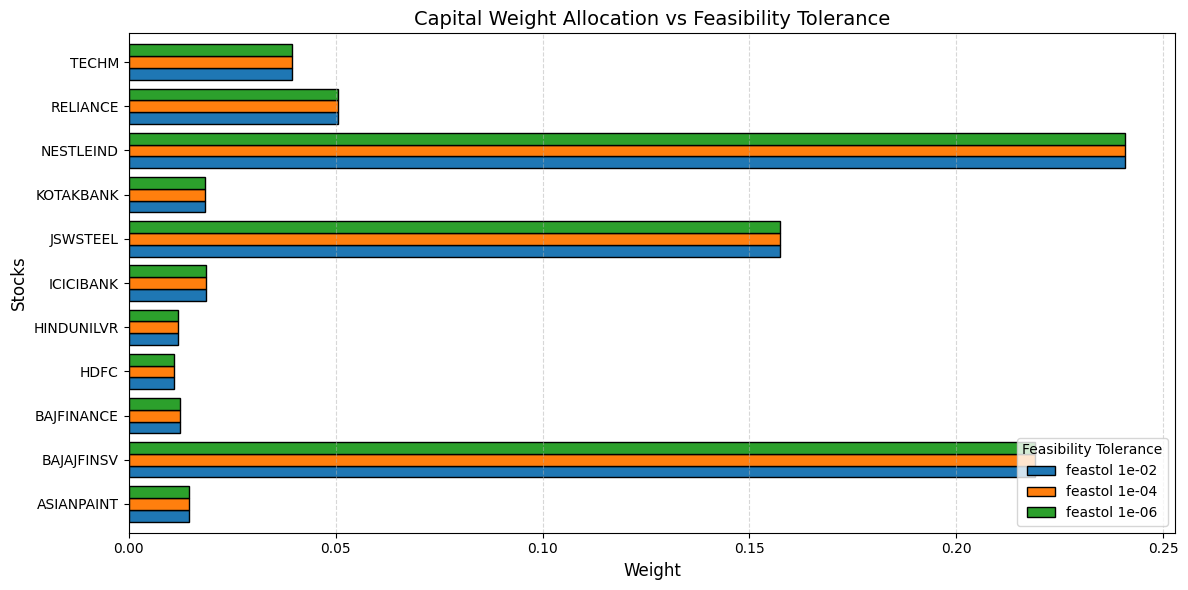

In [37]:
tols = [1e-2, 1e-4, 1e-6,]
target_return = 0.20

allocation_df = pd.DataFrame(index=prices.columns)

for tol in tols:
    w = cp.Variable(len(prices.columns))  
    
    risk = cp.quad_form(w, Sigma)
    objective = cp.Minimize(risk)
    
    constraints = [
        mu @ w >= target_return,
        cp.sum(w) == 1, 
        w >= 0
    ]
    
    # Solve
    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.ECOS, feastol=tol)
        
        # Store result
        if w.value is not None:
            cleaned_weights = np.where(w.value < 1e-5, 0, w.value)
            
            # Use scientific notation {: .0e} for cleaner column headers
            allocation_df[f"feastol {tol:.0e}"] = np.round(cleaned_weights, 4)
        else:
            print(f"Solver failed for feastol {tol:.0e}")
            
    except Exception as e:
        print(f"Optimization failed for {tol:.0e}: {e}")

# Filter out stocks that never exceed 1% allocation in any scenario
active_stocks = allocation_df[(allocation_df > 0.01).any(axis=1)]

if not active_stocks.empty:
    ax = active_stocks.plot(
        kind='barh', 
        figsize=(12, max(6, len(active_stocks) * 0.4)), 
        width=0.8,             
        edgecolor='black'     
    )

    plt.title("Capital Weight Allocation vs Feasibility Tolerance", fontsize=14)
    plt.xlabel("Weight", fontsize=12)  
    plt.ylabel("Stocks", fontsize=12)
    
    plt.grid(axis='x', linestyle='--', alpha=0.5) 
    
    plt.legend(title="Feasibility Tolerance", loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("No stocks met the 1% threshold for plotting.")

The plot indicates that the optimization problem is numerically stable. Tightening the solver's error tolerance did not change the optimal portfolio allocation. The solver found the same "Global Minimum" regardless of whether the tolerance was low or high.

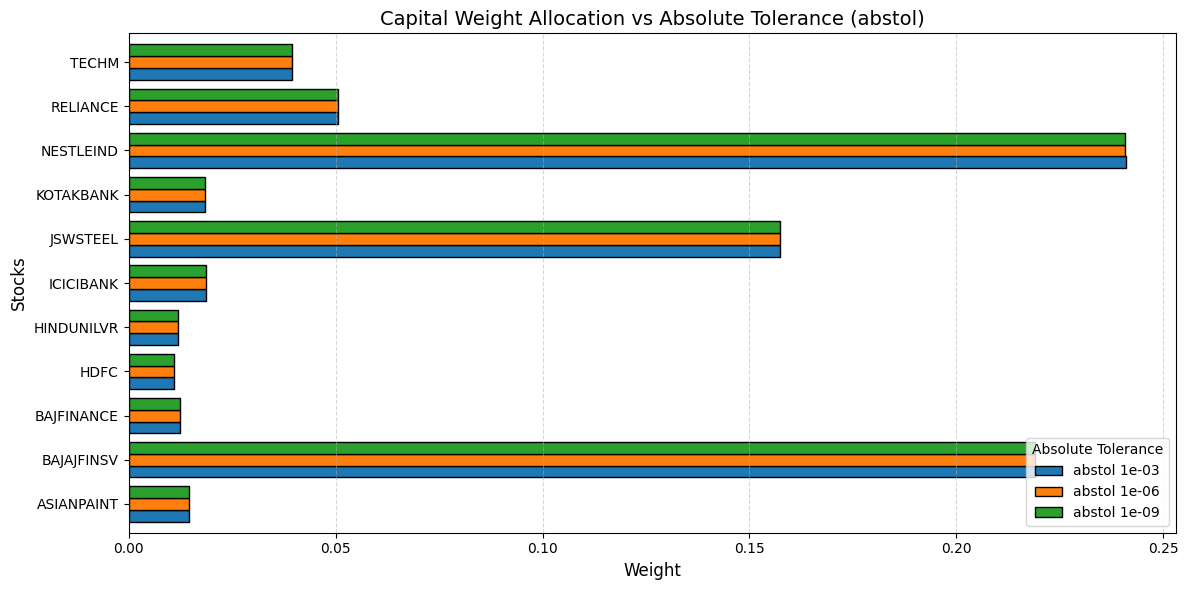

In [54]:
abstols = [1e-3, 1e-6, 1e-9] 
target_return = 0.20

# DataFrame to store weights (Index = Stock Names)
allocation_df = pd.DataFrame(index=prices.columns)

for tol in abstols:
    w = cp.Variable(len(prices.columns))
    
    risk = cp.quad_form(w, Sigma)
    objective = cp.Minimize(risk)
    
    constraints = [
        mu @ w >= target_return,
        cp.sum(w) == 1, 
        w >= 0
    ]
    
    # Solve
    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.ECOS, abstol=tol)
        
        # Store result
        if w.value is not None:
            cleaned_weights = np.where(w.value < 1e-5, 0, w.value)
            
            # Update column name to reflect abstol
            allocation_df[f"abstol {tol:.0e}"] = np.round(cleaned_weights, 4)
        else:
            print(f"Solver failed for abstol {tol:.0e}")
            
    except Exception as e:
        print(f"Optimization failed for {tol:.0e}: {e}")

# Filter out stocks that never exceed 1% allocation in any scenario
active_stocks = allocation_df[(allocation_df > 0.01).any(axis=1)]

if not active_stocks.empty:
    ax = active_stocks.plot(
        kind='barh', 
        figsize=(12, max(6, len(active_stocks) * 0.4)), 
        width=0.8,             
        edgecolor='black'     
    )

    plt.title("Capital Weight Allocation vs Absolute Tolerance (abstol)", fontsize=14)
    plt.xlabel("Weight", fontsize=12)  
    plt.ylabel("Stocks", fontsize=12)
    
    plt.grid(axis='x', linestyle='--', alpha=0.5) 
    
    plt.legend(title="Absolute Tolerance", loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("No stocks met the 1% threshold for plotting.")

## Experimenting with Additional Constraints

1. Holding Constraints:
Practitioners always set limits on maximum positions to avoid overexposure and ensure diversification, that is, upper bounds 𝒖 on the portfolio elements.
2. Capital Budget Constraint:
Assuming no shorting and no other kind of leverage, the portfolio must satisfy the budget constraint $1^T𝒘 +𝑐 = 1$, which is linear and, hence, convex. Alternatively, it can be rewritten without the cash variable as $1^T𝒘 ≤ 1$.

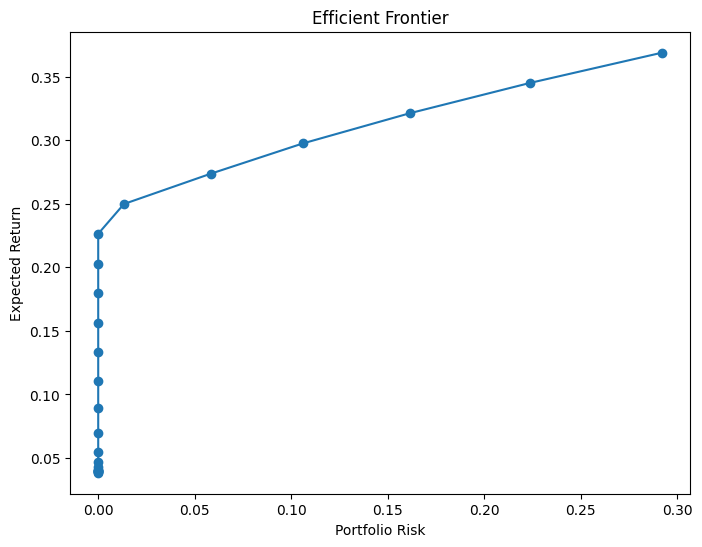

In [58]:
u = 0.20  #  Max allocation per stock

# decision variable
w = cp.Variable(n)

# portfolio variance
risk = cp.quad_form(w, Sigma)

# objective
objective = cp.Minimize(risk)

constraints = [
    # 0. No Short Selling
    w >= 0,
    # 1. Holding Constraints: No single position > u
    w <= u,
    # 2. Capital Budget Constraint: sum(w) <= 1 (allows holding cash)
    cp.sum(w) <= 1,

]

# target returns grid
target_returns = np.linspace(mu.min(), mu.max(), 30)

risks = []
returns = []

for r in target_returns:
    # add return constraint
    ret_constraint = mu.T @ w >= r
    prob = cp.Problem(objective, constraints + [ret_constraint])
    
    prob.solve(solver=cp.ECOS)
    if r < 0.20:
        weights = w.value       
        ret = r

    if w.value is not None:
        risks.append(np.sqrt(risk.value))  # standard deviation
        returns.append(mu @ w.value)

# plot efficient frontier
plt.figure(figsize=(8,6))
plt.plot(risks, returns, marker='o')
plt.xlabel("Portfolio Risk")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.show()

We are getting higher risks for smaller expected returns with additional constraints compared to the case with basic constraints.

In [61]:
print(f"Weights at target return {ret:.0%} with holding constraint:", weights)

Weights at target return 18% with holding constraint: [0.00653435 0.02019678 0.01258453 0.00671788 0.17754177 0.01343981
 0.0048228  0.00546391 0.00414352 0.00533018 0.00604986 0.01175665
 0.0063342  0.00381011 0.00300864 0.00630239 0.01433111 0.0070715
 0.00542287 0.00994697 0.01623087 0.02771111 0.00748623 0.00469376
 0.00290432 0.00618395 0.14510086 0.02859445 0.01124436 0.00701812
 0.00520436 0.17155927 0.00583806 0.00436823 0.0106283  0.06870063
 0.00909299 0.01194442 0.00472587 0.00431188 0.00580162 0.00535538
 0.06134596 0.00632835 0.00785077 0.01035025 0.00671983 0.00445852]


In [62]:
weights.sum()

np.float64(0.9925625775153859)

In [51]:
print("Weights:", weights)

Weights: None


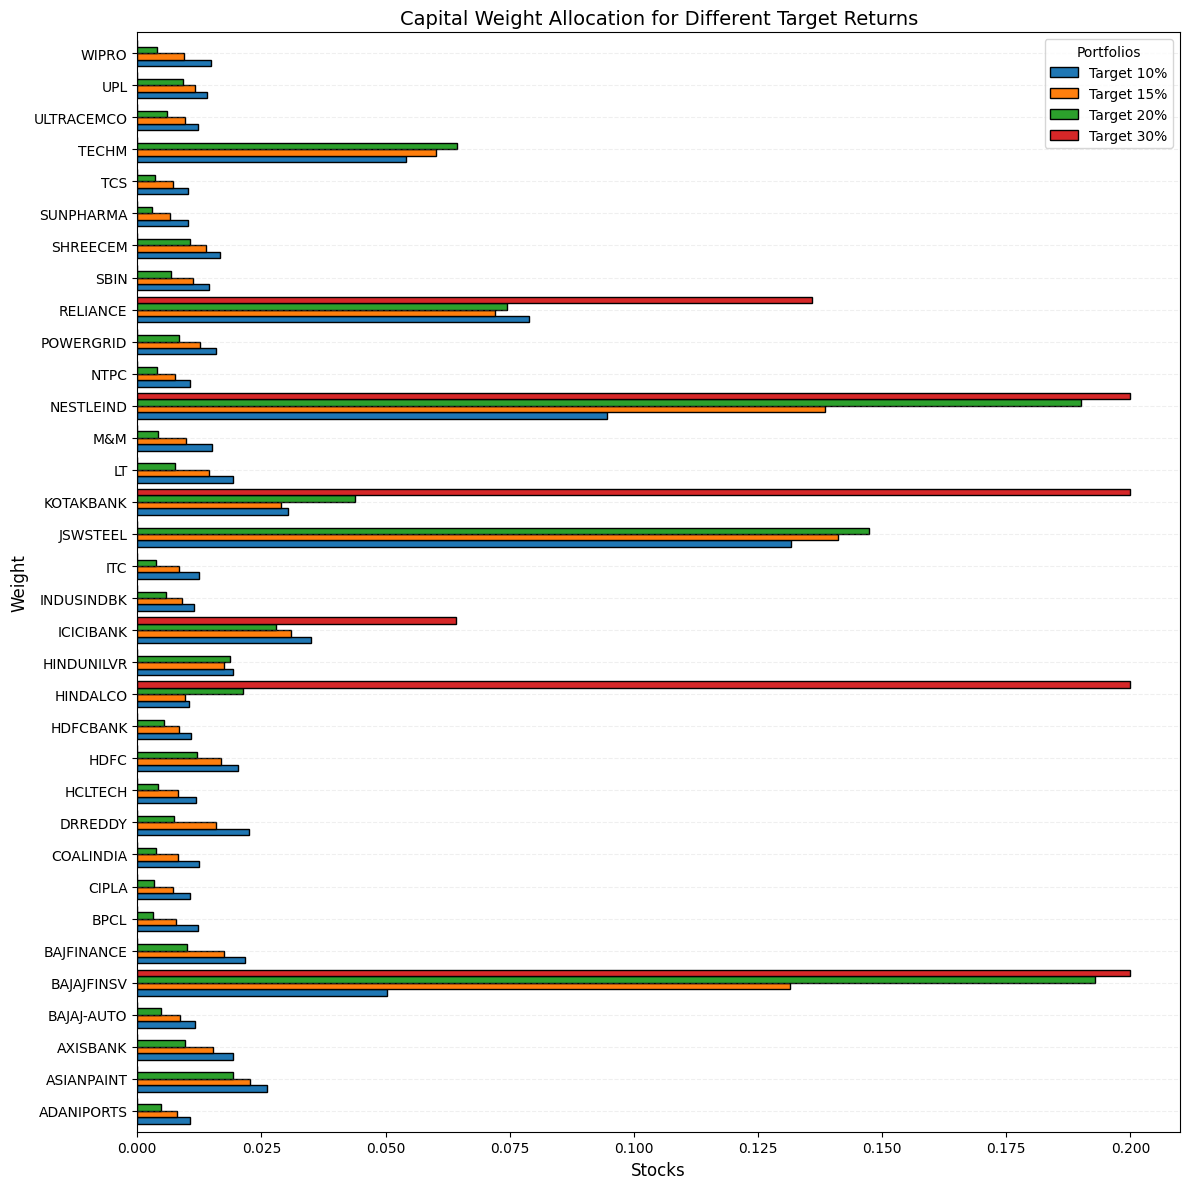

In [63]:
target_returns = [0.10, 0.15, 0.20, 0.30, ] 

# DataFrame to store weights (Index = Stock Names, Columns = Scenarios)
allocation_df = pd.DataFrame(index=prices.columns)

for r in target_returns:
    w = cp.Variable(n)
    
    risk = cp.quad_form(w, Sigma)
    objective = cp.Minimize(risk)
    
    constraints = [
        # 0. No Short Selling
        w >= 0,
        # 1. Holding Constraints: No single position > u
        w <= u,
        # 2. Capital Budget Constraint: sum(w) <= 1 (allows holding cash)
        cp.sum(w) <= 1,

    # Add return constraint 
        mu.T @ w >= r,
    ]
    
    # Solve
    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.ECOS)
        
        # Store result in DataFrame with a descriptive column name
        if w.value is not None:
            allocation_df[f"Target {r:.0%}"] = np.round(w.value, 4)
        else:
            print(f"Solver failed for target {r:.0%}")
            
    except Exception as e:
        print(f"Optimization failed for {r:.0%}: {e}")

active_stocks = allocation_df[(allocation_df > 0.01).any(axis=1)]

# Plotting
ax = active_stocks.plot(
    kind='barh', 
    figsize=(12, 12), 
    width=0.8,             
    edgecolor='black'     
)

plt.title("Capital Weight Allocation for Different Target Returns", fontsize=14)
plt.xlabel("Stocks", fontsize=12)
plt.ylabel("Weight", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.legend(title="Portfolios", loc="upper right")
plt.tight_layout()

plt.show()

There is a drastic change in porfolio weights as we increase the expected return threshold. Even for higher expected returns holding cash seems to be bad choice (weights.sum is approx 1).